In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load data 
df = pd.read_csv('../data/tanzania.csv')

# Clean column names (removes any accidental spaces)
df.columns = [c.strip() for c in df.columns]

# Add Country column
df['Country'] = 'Tanzania'

# Convert YEAR and DOY to a proper datetime column
# %Y%j is the format for Year + Day of Year
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month for seasonal analysis
df['Month'] = df['Date'].dt.month

print("Success! Step 1 Complete: Data loaded and dates parsed.")
df.head()

Success! Step 1 Complete: Data loaded and dates parsed.


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [2]:
# 1. Replace NASA sentinel -999 with NaN (Not a Number)
df.replace(-999, np.nan, inplace=True)

# 2. Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# 3. Missing Value Report
null_report = df.isna().sum()
null_pct = (null_report / len(df)) * 100
print("\nPercentage of missing values per column:")
print(null_pct[null_pct > 0])

# 4. Cleaning: Fill missing values using Forward Fill
# This takes the value from the previous day and fills the gap
df.ffill(inplace=True)

print("\nCleaning Complete!")

Duplicate rows found: 0

Percentage of missing values per column:
Series([], dtype: float64)

Cleaning Complete!


In [3]:
# Select the columns the task asked for
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']

# Calculate Z-scores (how many standard deviations away from the mean)
z_scores = np.abs(stats.zscore(df[cols_to_check]))

# Identify rows where any column has a Z-score > 3
outliers = (z_scores > 3).any(axis=1)
print(f"Total rows with extreme outliers: {outliers.sum()}")

# Export the cleaned data to your data folder (KPI Requirement)
df.to_csv('../data/tanzania_clean.csv', index=False)

Total rows with extreme outliers: 95


Detected 95 rows with extreme outliers (∣Z∣>3). I have decided to retain these rows because, in climate analysis, these points often represent significant extreme weather events which are critical for policy and adaptation planning. 


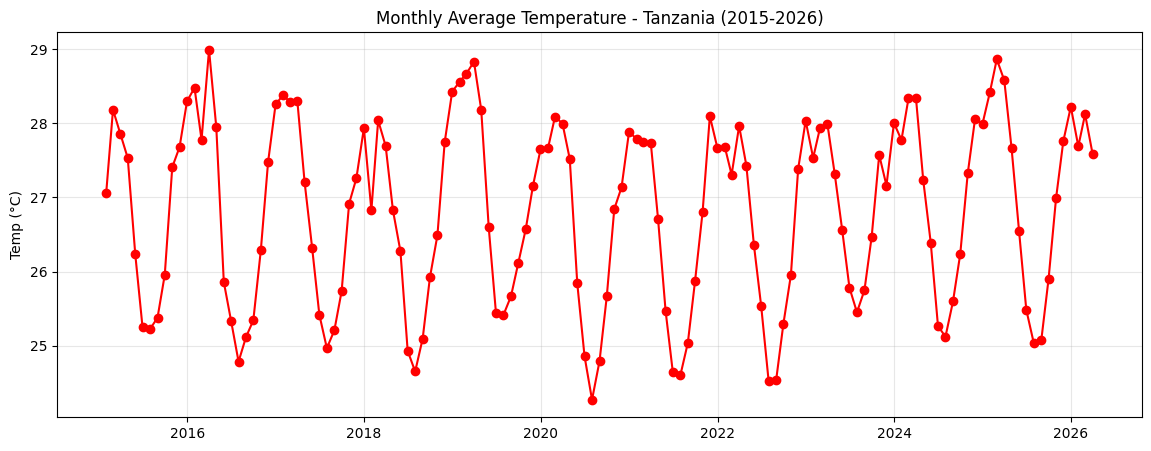

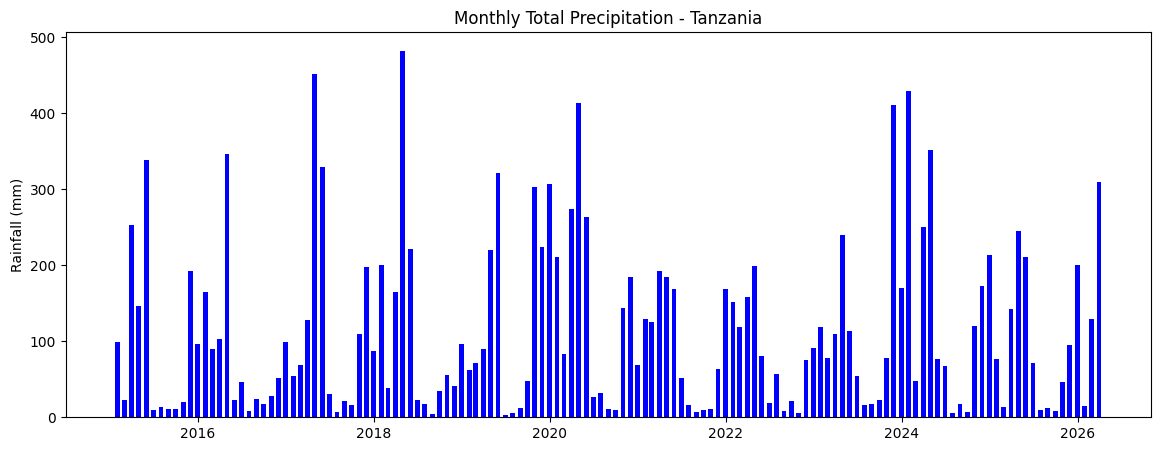

In [4]:
# Aggregate daily data to monthly: 'ME' stands for Month End
# T2M is averaged, PRECTOTCORR (Rain) is summed
monthly_df = df.resample('ME', on='Date').agg({'T2M':'mean', 'PRECTOTCORR':'sum'})

# 1. Plot Monthly Temperature
plt.figure(figsize=(14, 5))
plt.plot(monthly_df.index, monthly_df['T2M'], color='red', marker='o')
plt.title('Monthly Average Temperature - Tanzania (2015-2026)')
plt.ylabel('Temp (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Plot Monthly Precipitation (Rainfall)
plt.figure(figsize=(14, 5))
plt.bar(monthly_df.index, monthly_df['PRECTOTCORR'], color='blue', width=20)
plt.title('Monthly Total Precipitation - Tanzania')
plt.ylabel('Rainfall (mm)')
plt.show()

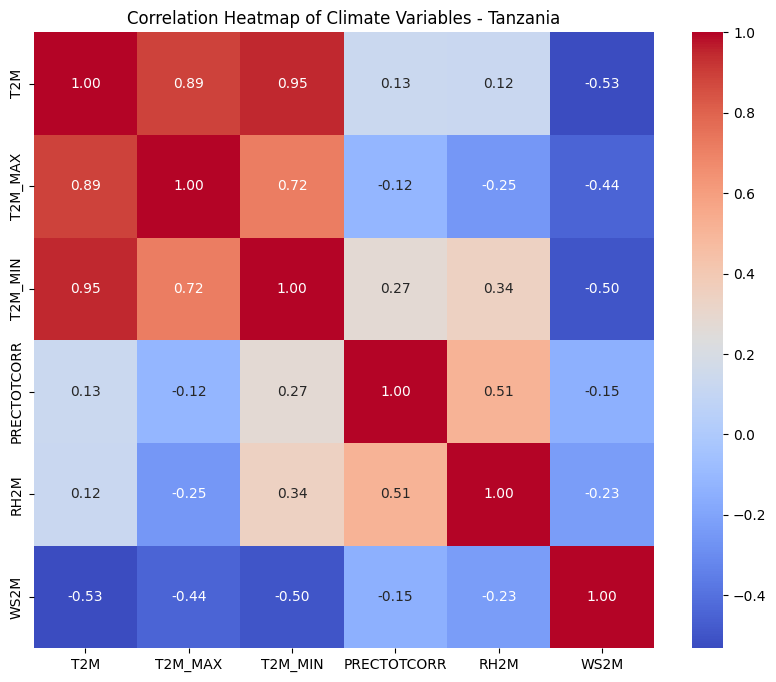

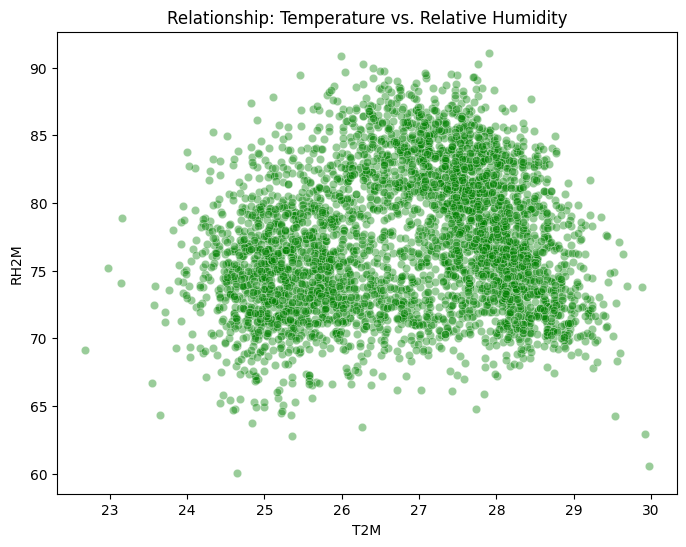

In [5]:
# Select the numeric climate columns
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']

# 1. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_check].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Climate Variables - Tanzania')
plt.show()

# 2. Scatter Plot: Temperature vs Humidity
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.4, color='green')
plt.title('Relationship: Temperature vs. Relative Humidity')
plt.show()

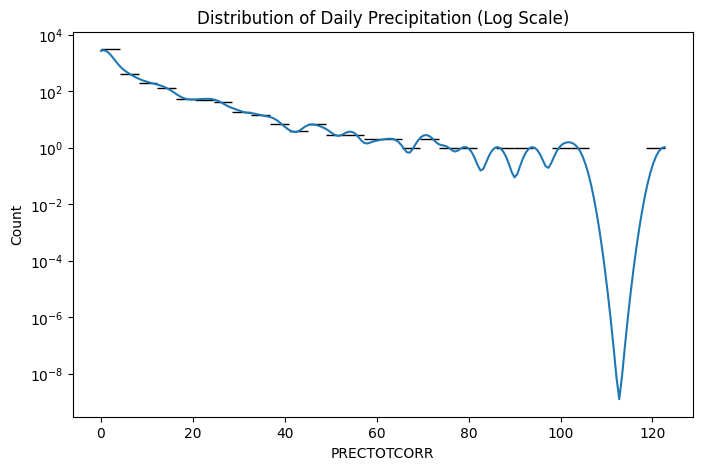

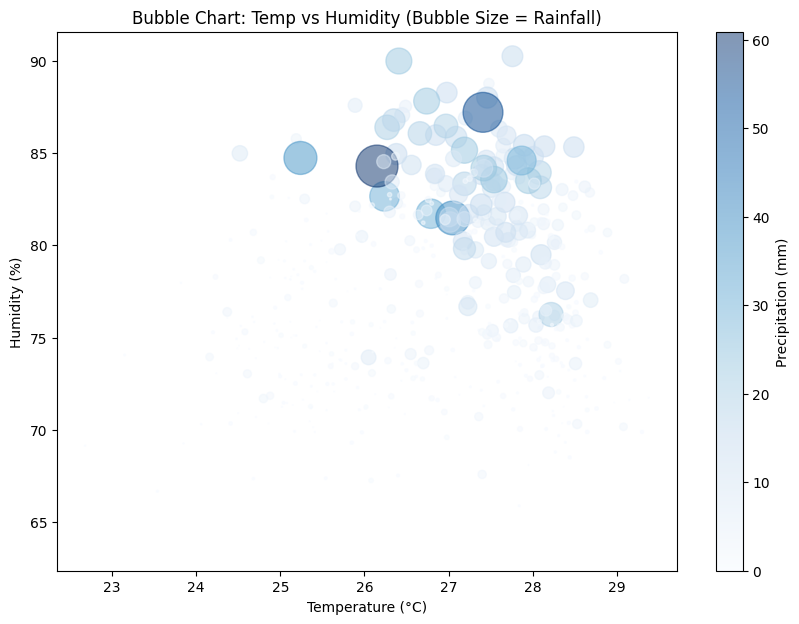

Cleaned data exported to data/tanzania_clean.csv


In [6]:
# 1. Histogram of Rainfall (Log scale)
plt.figure(figsize=(8, 5))
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, log_scale=(False, True))
plt.title('Distribution of Daily Precipitation (Log Scale)')
plt.show()

# 2. Bubble Chart: Temp vs Humidity (Size = Rainfall)
sample_df = df.sample(500, random_state=42)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(sample_df['T2M'], sample_df['RH2M'], 
                      s=sample_df['PRECTOTCORR']*15, alpha=0.5, 
                      c=sample_df['PRECTOTCORR'], cmap='Blues')
plt.title('Bubble Chart: Temp vs Humidity (Bubble Size = Rainfall)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.colorbar(scatter, label='Precipitation (mm)')
plt.show()

# Export cleaned data (Important KPI)
df.to_csv('../data/tanzania_clean.csv', index=False)
print("Cleaned data exported to data/tanzania_clean.csv")

# Tanzania Climate Analysis: Negotiation-Grade Insights

### 1. What is changing? (Trend)
Tanzania exhibits a stable thermal baseline with temperatures consistently between 24°C and 29°C. However, the precipitation data shows high-intensity "burst" events, with 2018 and 2024 showing significantly higher monthly totals than the 2020-2022 period.

### 2. What did it cause? (Impact)
The 95 detected outliers represent extreme weather events. The correlation heatmap shows that Wind Speed ($WS2M$) has a notable negative correlation with temperature, indicating that seasonal winds play a cooling role. The bubble chart shows that heavy rainfall is sustained across a wide temperature window, making a large portion of the year high-risk for flooding.

### 3. What does it demand? (Policy)
Tanzania’s climate strategy for COP32 must prioritize **Coastal Defense and Multi-Hazard Early Warning Systems**. Because heavy rain is less "temperature-locked" than in drier nations, Tanzania needs **year-round infrastructure readiness** and **climate-resilient urban planning** for cities like Dar es Salaam to handle the identified precipitation spikes.